# 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2.Load Dataset

In [2]:
df = pd.read_csv("car data.csv")

# 3. Explore the dataset

### Display first five rows


In [3]:
df.head() 

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:

df.info() # check dataset information
df.isnull().sum() # Check missing values
print("Rows and Columns :", df.shape) # Dataset shape


<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Selling_type   301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB
Rows and Columns : (301, 9)


# 4.Statistical Summary

In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# 5. Check Duplicate Values

In [6]:
df.duplicated().sum()


np.int64(2)

### Remove Duplicate values

In [7]:
df = df.drop_duplicates()


### After Removing Duplicate Values

In [8]:
df.duplicated().sum()

np.int64(0)

# 6.Encode Categorical Columns

In [9]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['Car_Name'] = encoder.fit_transform(df['Car_Name'])
df['Fuel_Type'] = encoder.fit_transform(df['Fuel_Type'])
df['Selling_type'] = encoder.fit_transform(df['Selling_type'])
df['Transmission'] = encoder.fit_transform(df['Transmission'])

# 7.Display Updated Dataset

In [10]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,90,2014,3.35,5.59,27000,2,0,1,0
1,93,2013,4.75,9.54,43000,1,0,1,0
2,68,2017,7.25,9.85,6900,2,0,1,0
3,96,2011,2.85,4.15,5200,2,0,1,0
4,92,2014,4.60,6.87,42450,1,0,1,0


# 8.Define Features and Target

In [11]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

# 9.Train-Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 10.Train Linear Regression Model

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


# 11.Predict Prices

In [14]:
y_pred = model.predict(X_test)

# 12.Model Evaluation

### Mean Absolute error

In [15]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE :", mae)

MAE : 1.5719610024166288


### Mean Squared Error

In [16]:
mse = mean_squared_error(y_test, y_pred)

print("MSE :", mse)

MSE : 6.830668277838222


### Root Mean Squared Error

In [17]:
rmse = np.sqrt(mse)

print("RMSE :", rmse)

RMSE : 2.6135547206512095


### R² Score

In [18]:
r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)

R2 Score : 0.734970753064054


# 13.Compare Actual vs Predicted Prices

In [19]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
283,8.99,7.500574
267,8.35,7.536522
166,0.45,1.317204
9,7.45,6.760742
78,5.25,11.225934
280,5.25,4.489811
95,5.85,8.546360
111,1.15,1.790735
5,9.25,8.719983
175,0.38,-1.007439


# 14.Scatter Plot

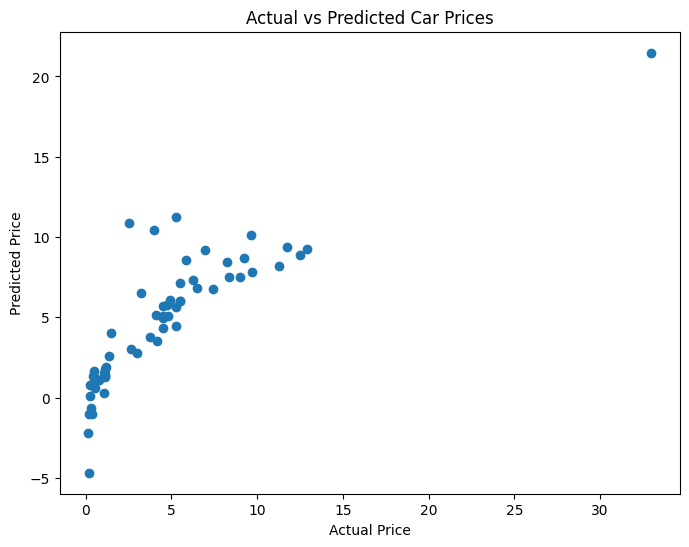

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

# 15.Feature Importance (Model Coefficients)

In [21]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

importance

,Feature,Coefficient
0,Car_Name,0.005531
1,Year,0.343673
2,Present_Price,0.440564
3,Driven_kms,-0.000009
4,Fuel_Type,-1.191077
5,Selling_type,-1.058777
6,Transmission,-1.582775
7,Owner,0.767133


# 16.Predict Price of a New Car

In [22]:
sample_car = pd.DataFrame([[
    20,      # Car_Name 
    5.59,    # Present_Price
    27000,   # Driven_KMs
    1,       # Fuel_Type
    0,       # Selling_Type
    1,       # Transmission
    0,       # Owner
    12,      # Car_Age
    
]], columns=X.columns)

prediction = model.predict(sample_car)

print("Predicted Selling Price:", prediction[0])

Predicted Selling Price: 11218.541134073372


# 17.Insights

### Car age has a negative impact on selling price.
### Selling type has an impact on price.
### The Linear Regression model provides a good prediction of car prices.

# 18.Conclusion

### Built a Linear Regression model to predict car selling prices using multiple car features.
### Performed data preprocessing, feature engineering, and categorical encoding to prepare the dataset.
### Evaluated the model using MAE, RMSE, and R² Score, demonstrating how machine learning can estimate used car prices effectively.